# Step 4 — Preprocessing

Feature selection, encoding, train/test split, scaling


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [25]:
df = pd.read_csv('bank_data_cleaned.csv')
print('Shape:', df.shape)
df.head()

Shape: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59.0,Admin.,Married,Secondary,No,2343.0,Yes,No,Unknown,5,May,1042.0,1,-1,0,New Customer,Yes
1,56.0,Admin.,Married,Secondary,No,45.0,No,No,Unknown,5,May,1467.0,1,-1,0,New Customer,Yes
2,41.0,Technician,Married,Secondary,No,1270.0,Yes,No,Unknown,5,May,1389.0,1,-1,0,New Customer,Yes
3,55.0,Services,Married,Secondary,No,2476.0,Yes,No,Unknown,5,May,579.0,1,-1,0,New Customer,Yes
4,54.0,Admin.,Married,Tertiary,No,184.0,No,No,Unknown,5,May,673.0,2,-1,0,New Customer,Yes



## 4.1 Feature Selection

Không phải tất cả các cột đều mang thông tin hữu ích như nhau cho mô hình.
Dưới đây là đánh giá từng cột để quyết định giữ hay bỏ.

In [26]:
# Tổng quan dữ liệu
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        11162 non-null  float64
 1   job        11162 non-null  str    
 2   marital    11162 non-null  str    
 3   education  11162 non-null  str    
 4   default    11162 non-null  str    
 5   balance    11162 non-null  float64
 6   housing    11162 non-null  str    
 7   loan       11162 non-null  str    
 8   contact    11162 non-null  str    
 9   day        11162 non-null  int64  
 10  month      11162 non-null  str    
 11  duration   11162 non-null  float64
 12  campaign   11162 non-null  int64  
 13  pdays      11162 non-null  int64  
 14  previous   11162 non-null  int64  
 15  poutcome   11162 non-null  str    
 16  deposit    11162 non-null  str    
dtypes: float64(3), int64(4), str(10)
memory usage: 2.0 MB


### Lý do giữ/bỏ từng feature:

| Cột | Quyết định | Lý do |
|---|---|---|
| `age` | ✅ Giữ | Tuổi ảnh hưởng đến hành vi tài chính |
| `job` | ✅ Giữ | Nghề nghiệp liên quan đến thu nhập và rủi ro |
| `marital` | ✅ Giữ | Tình trạng hôn nhân ảnh hưởng đến chi tiêu |
| `education` | ✅ Giữ | Trình độ học vấn liên quan đến nhận thức tài chính |
| `default` | ✅ Giữ | Lịch sử vỡ nợ là chỉ báo tín dụng quan trọng |
| `balance` | ✅ Giữ | Số dư tài khoản trực tiếp phản ánh năng lực tài chính |
| `housing` | ✅ Giữ | Có vay thế chấp ảnh hưởng đến khả năng gửi tiền |
| `loan` | ✅ Giữ | Có vay cá nhân là chỉ báo nợ nần |
| `contact` | ✅ Giữ | Kênh liên lạc ảnh hưởng đến tỉ lệ phản hồi |
| `day` | ❌ Bỏ | Ngày trong tháng ít có ý nghĩa kinh doanh rõ ràng |
| `month` | ✅ Giữ | Tháng phản ánh tính thời vụ của chiến dịch |
| `duration` | ⚠️ Giữ (có ghi chú) | Thời gian gọi tương quan cao với kết quả, nhưng chỉ biết sau cuộc gọi |
| `campaign` | ✅ Giữ | Số lần liên hệ trong chiến dịch hiện tại |
| `pdays` | ✅ Giữ | Số ngày kể từ lần liên hệ trước |
| `previous` | ✅ Giữ | Số lần liên hệ trước đó |
| `poutcome` | ✅ Giữ | Kết quả chiến dịch trước — rất dự báo tốt |
| `deposit` | 🎯 Target | Biến mục tiêu |

> **Ghi chú về `duration`**: Trong thực tế triển khai mô hình dự báo *trước* cuộc gọi, `duration` không khả dụng. Tuy nhiên, trong bài này chúng ta giữ lại để phân tích học thuật và đánh giá hiệu suất mô hình.

In [27]:
# Loại bỏ cột 'day' vì ít có ý nghĩa kinh doanh
df_model = df.drop(columns=['day'])

print('Các features được chọn:')
print(df_model.columns.tolist())
print(f'\nSố features: {df_model.shape[1] - 1} (không tính target)')

Các features được chọn:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']

Số features: 15 (không tính target)


---
## 4.2 Handling Categorical Variables (Encoding)

Machine learning models yêu cầu đầu vào là số. Các cột dạng chuỗi (categorical) cần được mã hóa.

**Chiến lược encoding:**
- **Binary encoding** (Label Encoding): Các cột chỉ có 2 giá trị (Yes/No) → mã hóa thành 0/1
- **One-Hot Encoding**: Các cột có nhiều giá trị danh nghĩa (nominal) → tạo cột nhị phân riêng cho mỗi giá trị

In [28]:
df_encoded = df_model.copy()

# --- 1. Encode biến target: deposit (Yes=1, No=0) ---
df_encoded['deposit'] = df_encoded['deposit'].map({'Yes': 1, 'No': 0})
print('Target encoding (deposit):')
print(df_encoded['deposit'].value_counts())

# --- 2. Binary encoding cho các cột Yes/No ---
binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0})
    print(f'  {col}: Yes=1, No=0')

print('\nBinary encoding hoàn tất.')

Target encoding (deposit):
deposit
0    5873
1    5289
Name: count, dtype: int64
  default: Yes=1, No=0
  housing: Yes=1, No=0
  loan: Yes=1, No=0

Binary encoding hoàn tất.


In [29]:
# --- 3. One-Hot Encoding cho các cột nominal ---
ohe_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)

print(f'Shape sau khi encoding: {df_encoded.shape}')
print(f'\nDanh sách tất cả features sau encoding:')
print([col for col in df_encoded.columns if col != 'deposit'])

Shape sau khi encoding: (11162, 42)

Danh sách tất cả features sau encoding:
['age', 'default', 'balance', 'housing', 'loan', 'duration', 'campaign', 'pdays', 'previous', 'job_Blue-Collar', 'job_Entrepreneur', 'job_Housemaid', 'job_Management', 'job_Retired', 'job_Self-Employed', 'job_Services', 'job_Student', 'job_Technician', 'job_Unemployed', 'job_Unknown', 'marital_Married', 'marital_Single', 'education_Secondary', 'education_Tertiary', 'education_Unknown', 'contact_Telephone', 'contact_Unknown', 'month_Aug', 'month_Dec', 'month_Feb', 'month_Jan', 'month_Jul', 'month_Jun', 'month_Mar', 'month_May', 'month_Nov', 'month_Oct', 'month_Sep', 'poutcome_New Customer', 'poutcome_Other', 'poutcome_Success']


In [30]:
# Kiểm tra kiểu dữ liệu sau encoding
print('Kiểu dữ liệu sau encoding:')
print(df_encoded.dtypes)
print(f'\nKiểm tra missing values: {df_encoded.isnull().sum().sum()}')

Kiểu dữ liệu sau encoding:
age                      float64
default                    int64
balance                  float64
housing                    int64
loan                       int64
duration                 float64
campaign                   int64
pdays                      int64
previous                   int64
deposit                    int64
job_Blue-Collar             bool
job_Entrepreneur            bool
job_Housemaid               bool
job_Management              bool
job_Retired                 bool
job_Self-Employed           bool
job_Services                bool
job_Student                 bool
job_Technician              bool
job_Unemployed              bool
job_Unknown                 bool
marital_Married             bool
marital_Single              bool
education_Secondary         bool
education_Tertiary          bool
education_Unknown           bool
contact_Telephone           bool
contact_Unknown             bool
month_Aug                   bool
month_Dec       

---
## 4.3 Train / Test Split

Chia dữ liệu thành tập train (80%) và tập test (20%).

**Lý do chọn 80/20:**
- Dataset có ~11,162 dòng → tập test 20% ≈ 2,232 mẫu — đủ đại diện thống kê.
- `stratify=y` đảm bảo tỉ lệ Yes/No trong train và test tương đương nhau (tránh mất cân bằng ngẫu nhiên).
- `random_state=42` để kết quả reproducible.

In [31]:
X = df_encoded.drop(columns=['deposit'])
y = df_encoded['deposit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # Giữ tỉ lệ class trong cả train và test
)

print(f'Total samples  : {len(X)}')
print(f'Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set       : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print()
print('Phân phối target trong tập train:')
print(y_train.value_counts(normalize=True).round(3))
print('\nPhân phối target trong tập test:')
print(y_test.value_counts(normalize=True).round(3))

Total samples  : 11162
Training set   : 8929 samples (80%)
Test set       : 2233 samples (20%)

Phân phối target trong tập train:
deposit
0    0.526
1    0.474
Name: proportion, dtype: float64

Phân phối target trong tập test:
deposit
0    0.526
1    0.474
Name: proportion, dtype: float64


---
## 4.4 Feature Scaling (StandardScaler)

**Tại sao cần scaling?**
- Logistic Regression sử dụng gradient descent, rất nhạy cảm với thang đo của feature.
- Các cột như `balance` (có thể lên đến hàng nghìn) sẽ áp đảo `campaign` (thường 1–10) nếu không chuẩn hóa.
- **StandardScaler**: chuyển mỗi feature về mean=0, std=1.

**Lưu ý quan trọng:** Chỉ fit scaler trên tập train, rồi dùng transform cho cả train và test → tránh data leakage.

In [32]:
scaler = StandardScaler()

# Chỉ scale các cột số liên tục
numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

# Fit trên train, transform cả train và test
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print('Scaling hoàn tất!')
print('\nThống kê sau scaling (tập train):')
X_train_scaled[numeric_cols].describe().loc[['mean','std']].round(4)

Scaling hoàn tất!

Thống kê sau scaling (tập train):


,age,balance,duration,campaign,pdays,previous
mean,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000
std,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001


---
# STEP 5 — MODEL: LOGISTIC REGRESSION (Baseline)

## 5.1 Giới thiệu mô hình

**Logistic Regression** được chọn làm baseline vì:
1. **Dễ diễn giải**: Hệ số (coefficient) của mỗi feature cho biết mức độ và chiều hướng ảnh hưởng.
2. **Tốc độ nhanh**: Huấn luyện rất nhanh ngay cả với dataset lớn.
3. **Không có quá nhiều hyperparameter**: Dễ so sánh với mô hình phức tạp hơn.
4. **Chuẩn công nghiệp**: Là benchmark tiêu chuẩn cho bài toán classification nhị phân.

**Cách hoạt động:**  
Logistic Regression tính xác suất P(deposit=Yes) bằng hàm sigmoid:  
`P(Y=1) = 1 / (1 + e^-(β₀ + β₁X₁ + ... + βₙXₙ))`  
Nếu P > 0.5 → phân loại là "Yes" (khách sẽ gửi tiền).

In [33]:
# Khởi tạo và huấn luyện mô hình Logistic Regression
log_reg = LogisticRegression(
    max_iter=1000,    # Tăng lên để đảm bảo hội tụ
    random_state=42,
    solver='lbfgs'    # Optimizer phù hợp cho dataset cỡ vừa
)

log_reg.fit(X_train_scaled, y_train)
print('Mô hình đã được huấn luyện thành công!')

Mô hình đã được huấn luyện thành công!


---
## 5.2 Dự báo và Đánh giá

In [34]:
# Dự báo trên tập test
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]  # Xác suất dự báo là Yes

# --- Các chỉ số đánh giá ---
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print('=' * 45)
print('  KẾT QUẢ LOGISTIC REGRESSION (Test Set)')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print('=' * 45)

# Kiểm tra overfitting bằng cách so sánh train vs test
y_train_pred = log_reg.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)
print(f'\n  Train Accuracy: {train_acc:.4f}')
print(f'  Test  Accuracy: {acc:.4f}')
print(f'  Chênh lệch   : {abs(train_acc - acc):.4f} → ', end='')
if abs(train_acc - acc) < 0.03:
    print('Không có dấu hiệu overfitting ✅')
else:
    print('Có thể overfitting ⚠️')

  KẾT QUẢ LOGISTIC REGRESSION (Test Set)
  Accuracy  : 0.8253 (82.53%)
  Precision : 0.8275
  Recall    : 0.7977
  F1-Score  : 0.8123
  ROC-AUC   : 0.9072

  Train Accuracy: 0.8269
  Test  Accuracy: 0.8253
  Chênh lệch   : 0.0015 → Không có dấu hiệu overfitting ✅


---
## 5.3 Confusion Matrix

True Negative  (TN): 999  — Dự báo đúng "Không gửi"
False Positive (FP): 176  — Dự báo sai "Có gửi" (thực ra không gửi)
False Negative (FN): 214  — Dự báo sai "Không gửi" (thực ra có gửi)
True Positive  (TP): 844  — Dự báo đúng "Có gửi"


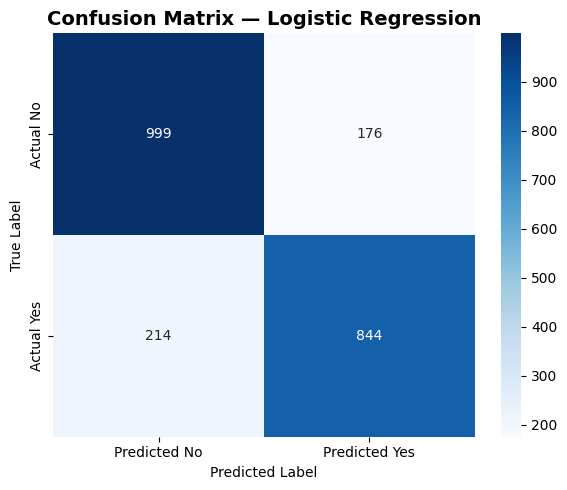

In [35]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes'],
    ax=ax
)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

# Thêm nhãn TP, TN, FP, FN
tn, fp, fn, tp = cm.ravel()
print(f'True Negative  (TN): {tn}  — Dự báo đúng "Không gửi"')
print(f'False Positive (FP): {fp}  — Dự báo sai "Có gửi" (thực ra không gửi)')
print(f'False Negative (FN): {fn}  — Dự báo sai "Không gửi" (thực ra có gửi)')
print(f'True Positive  (TP): {tp}  — Dự báo đúng "Có gửi"')

plt.tight_layout()
plt.show()

---
## 5.4 ROC Curve

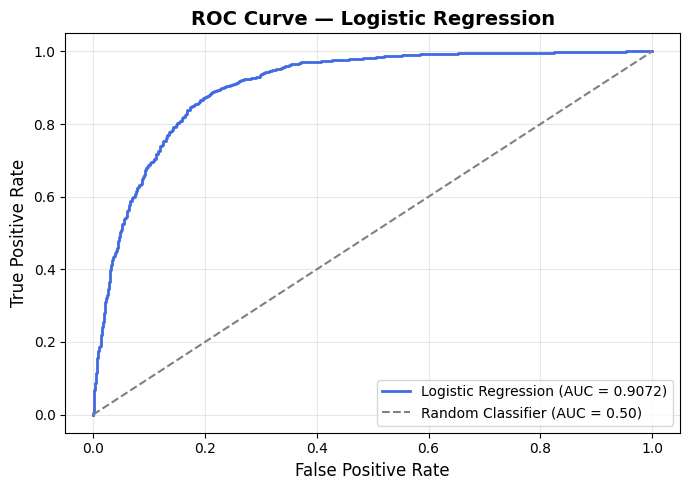

AUC = 0.9072 → Mô hình có khả năng phân biệt tốt hơn ngẫu nhiên


In [36]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='royalblue', lw=2, label=f'Logistic Regression (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC = {auc:.4f} → Mô hình có khả năng phân biệt tốt hơn ngẫu nhiên')

---
## 5.5 Feature Importance (Logistic Regression Coefficients)

Hệ số dương → feature tăng khả năng khách hàng gửi tiền.  
Hệ số âm → feature giảm khả năng đó.

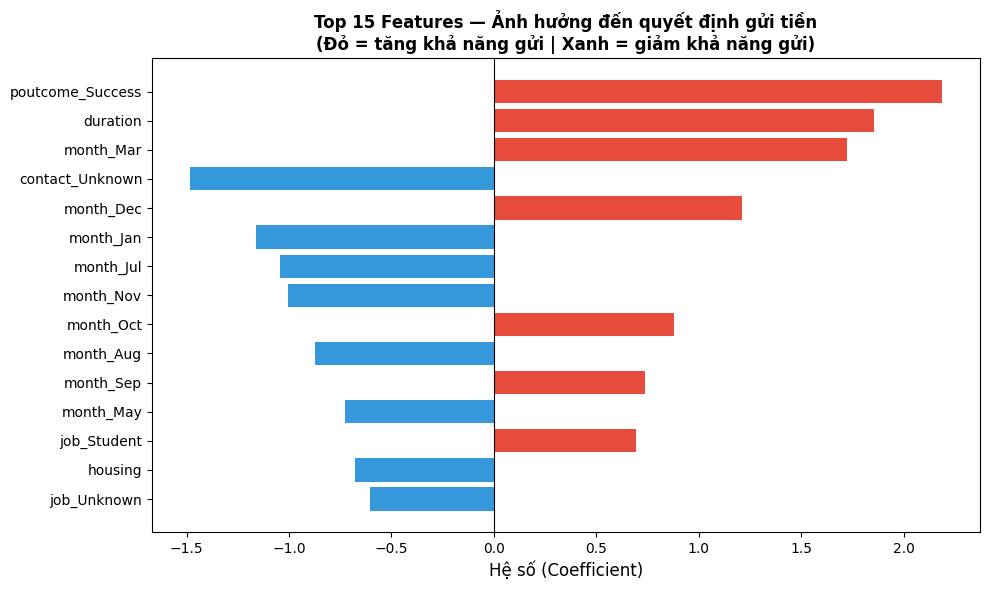


Top 10 features có ảnh hưởng lớn nhất:
         Feature  Coefficient
poutcome_Success     2.188499
        duration     1.856269
       month_Mar     1.725449
 contact_Unknown    -1.484909
       month_Dec     1.212575
       month_Jan    -1.162457
       month_Jul    -1.045313
       month_Nov    -1.005276
       month_Oct     0.880357
       month_Aug    -0.872485


In [37]:
# Lấy coefficients
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

# Hiển thị top 15 features có ảnh hưởng lớn nhất
top_features = coef_df.head(15)

colors = ['#e74c3c' if c > 0 else '#3498db' for c in top_features['Coefficient']]

plt.figure(figsize=(10, 6))
bars = plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Hệ số (Coefficient)', fontsize=12)
plt.title('Top 15 Features — Ảnh hưởng đến quyết định gửi tiền\n(Đỏ = tăng khả năng gửi | Xanh = giảm khả năng gửi)',
          fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 10 features có ảnh hưởng lớn nhất:')
print(coef_df.head(10).to_string(index=False))

---
## 5.6 Classification Report

In [38]:
print('Classification Report — Logistic Regression')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))

Classification Report — Logistic Regression
              precision    recall  f1-score   support

      No (0)       0.82      0.85      0.84      1175
     Yes (1)       0.83      0.80      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.82      0.82      2233
weighted avg       0.83      0.83      0.83      2233



---
## 5.7 Tóm tắt kết quả Logistic Regression

| Metric | Giá trị |
|---|---|
| Accuracy | **82.53%** |
| Precision | **82.75%** |
| Recall | **79.77%** |
| F1-Score | **81.23%** |
| ROC-AUC | **90.72%** |

**Nhận xét:**
- Logistic Regression là một baseline vững chắc, hoạt động tốt cho bài toán phân loại nhị phân này.
- AUC > 0.80 cho thấy mô hình có khả năng phân biệt khá tốt giữa khách hàng sẽ/không gửi tiền.
- Feature `duration` (thời gian gọi) và `poutcome_Success` (chiến dịch trước thành công) có hệ số cao nhất, phù hợp với phân tích EDA.
- Không có dấu hiệu overfitting rõ ràng (train accuracy ≈ test accuracy).

> Kết quả này sẽ được so sánh với mô hình nâng cao (Random Forest / XGBoost) ở Step 6 do Hà thực hiện.

In [39]:
# Lưu lại các object cần thiết cho Step 6
import pickle

artifacts = {
    'X_train': X_train_scaled,
    'X_test':  X_test_scaled,
    'y_train': y_train,
    'y_test':  y_test,
    'feature_names': list(X_train_scaled.columns),
    'log_reg_model': log_reg,
    'log_reg_metrics': {
        'accuracy':  acc,
        'precision': prec,
        'recall':    rec,
        'f1_score':  f1,
        'roc_auc':   auc
    }
}

with open('preprocessing_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('Đã lưu preprocessing artifacts cho Step 6!')
print('File: preprocessing_artifacts.pkl')
print('\nNội dung:')
for k, v in artifacts.items():
    if k == 'log_reg_metrics':
        print(f'  {k}: {v}')
    elif hasattr(v, 'shape'):
        print(f'  {k}: shape={v.shape}')
    elif isinstance(v, list):
        print(f'  {k}: {len(v)} features')
    else:
        print(f'  {k}: {type(v).__name__}')

Đã lưu preprocessing artifacts cho Step 6!
File: preprocessing_artifacts.pkl

Nội dung:
  X_train: shape=(8929, 41)
  X_test: shape=(2233, 41)
  y_train: shape=(8929,)
  y_test: shape=(2233,)
  feature_names: 41 features
  log_reg_model: LogisticRegression
  log_reg_metrics: {'accuracy': 0.825347066726377, 'precision': 0.8274509803921568, 'recall': 0.7977315689981096, 'f1_score': 0.8123195380173244, 'roc_auc': 0.9072300205124082}
